Recommended to use virtual env:

1. python -m venv .venv
2. .venv\Scripts\activate
3. pip install -r requirements.txt

In [75]:
import pandas as pd

In [76]:
df = pd.read_csv('Fifa_world_cup_matches.csv', encoding='latin-1')

In [77]:
# Adds new 'result' column. 1 = Win, 0 = Loss
# Tracks whether Team 1 won or not.
goals_team_1 = pd.to_numeric(df['number of goals team1'])
goals_team_2 = pd.to_numeric(df['number of goals team2'])
df['result'] = (goals_team_1 > goals_team_2).astype(int)

print(df[['number of goals team1','number of goals team2','result']].head())


   number of goals team1  number of goals team2  result
0                      0                      2       0
1                      6                      2       1
2                      0                      2       0
3                      1                      1       0
4                      1                      2       0


In [78]:
df = df.drop(columns = ['team1', 'team2', 'date', 'hour', 'category']) # Unnecessary
df = df.drop(columns = ['number of goals team1', 'number of goals team2']) # Leaving it in gives the algorithm the answer to who one, resulting in an accuracy of 100%
df = df.drop(columns = ['conceded team1', 'conceded team2']) # sort of the same reason as above, kind of cheating for the algo

In [79]:
# Looks for cells with % in them and converts them into decimal (eg 56% -> 0.56)
percent_cols = [c for c in df.columns if df[c].astype(str).str.contains('%', na=False).any()]
if percent_cols:
    df[percent_cols] = df[percent_cols].apply(
        lambda col: col.astype(str).str.replace(r'[%\s]', '', regex=True).replace('', pd.NA).astype(float) / 100
    )

In [80]:
X = df.iloc[:, :-1] # Selects all but the result column
y = df.iloc[:, -1] # Selects only the results column, the target variable we want to predict

In [81]:
from sklearn.model_selection import train_test_split
# 20% Test / 80% Train
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 17, test_size = 0.2)

In [82]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [87]:
y_pred = rf.predict(X_test)
rf.score(X_test, y_test)

0.6923076923076923

Num RandomForest trees: 100


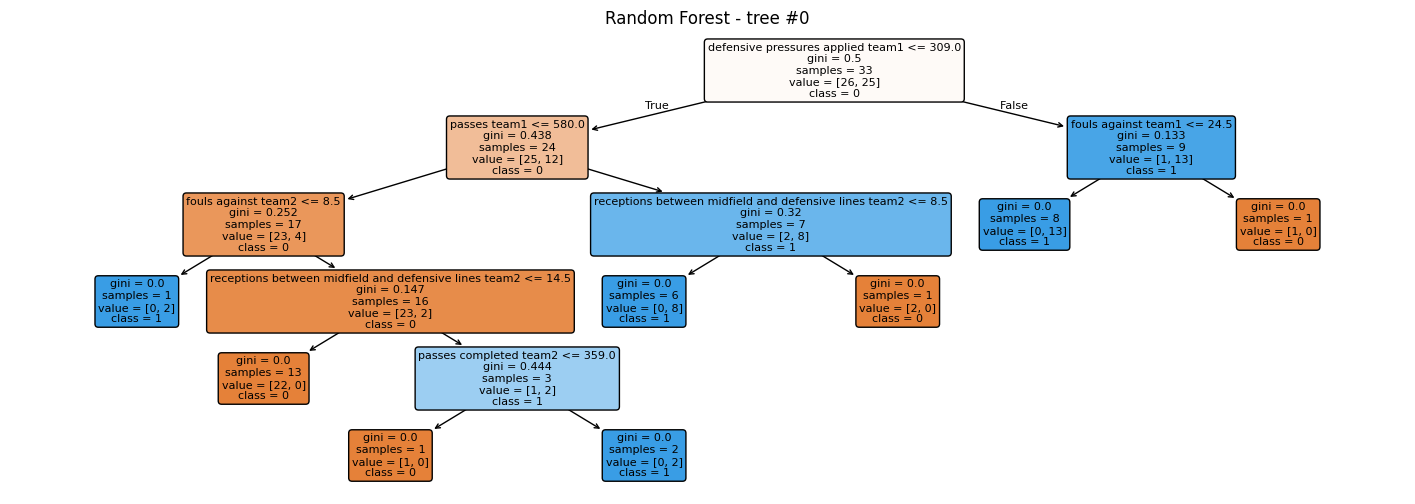

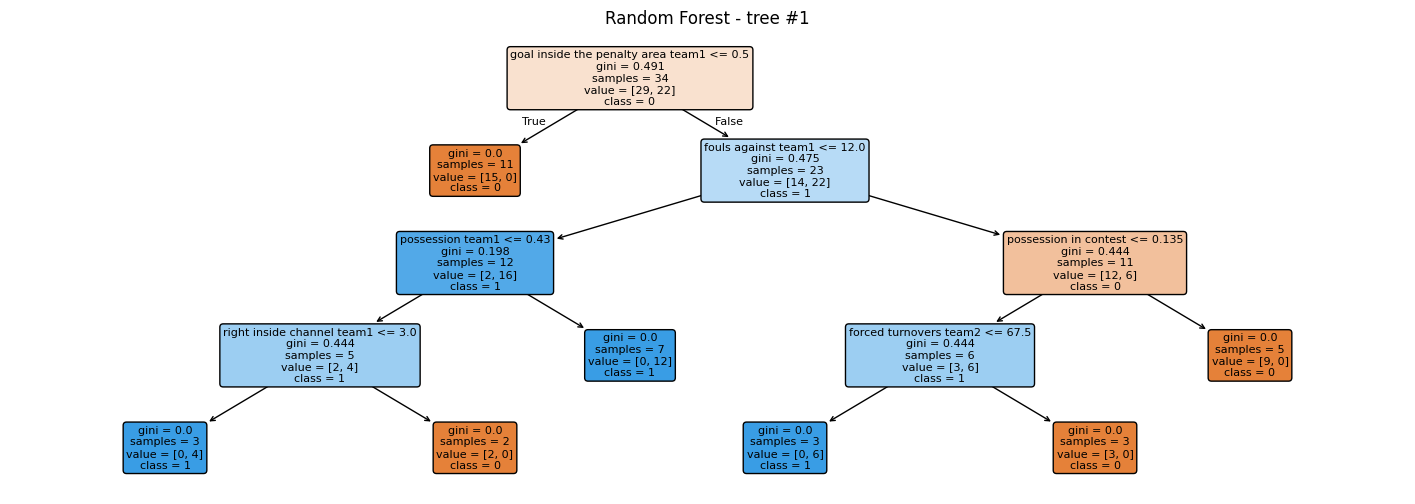

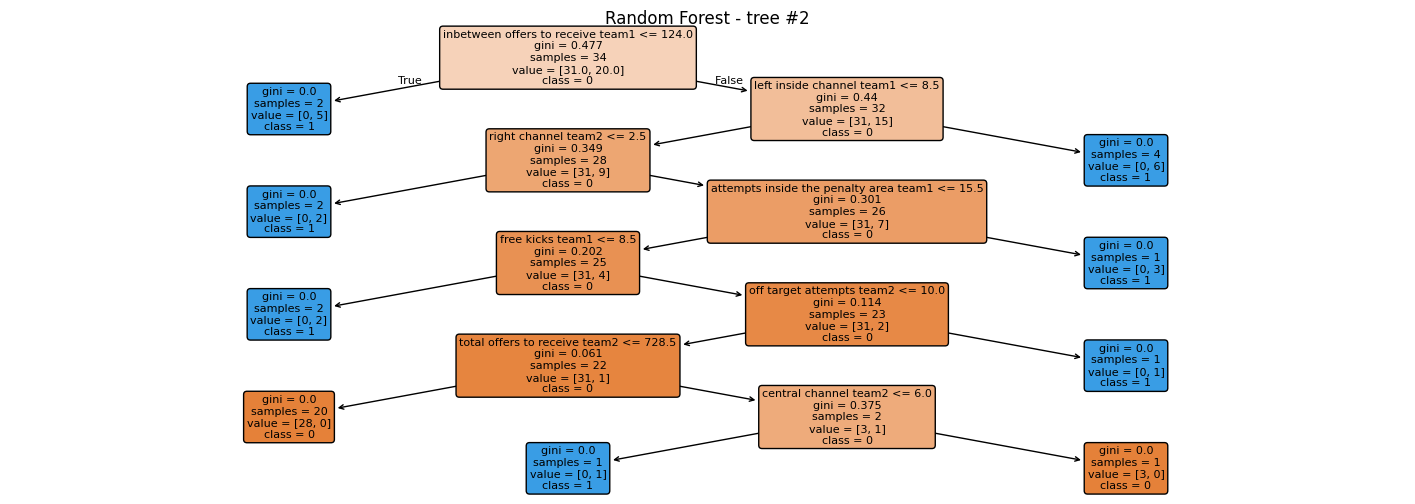

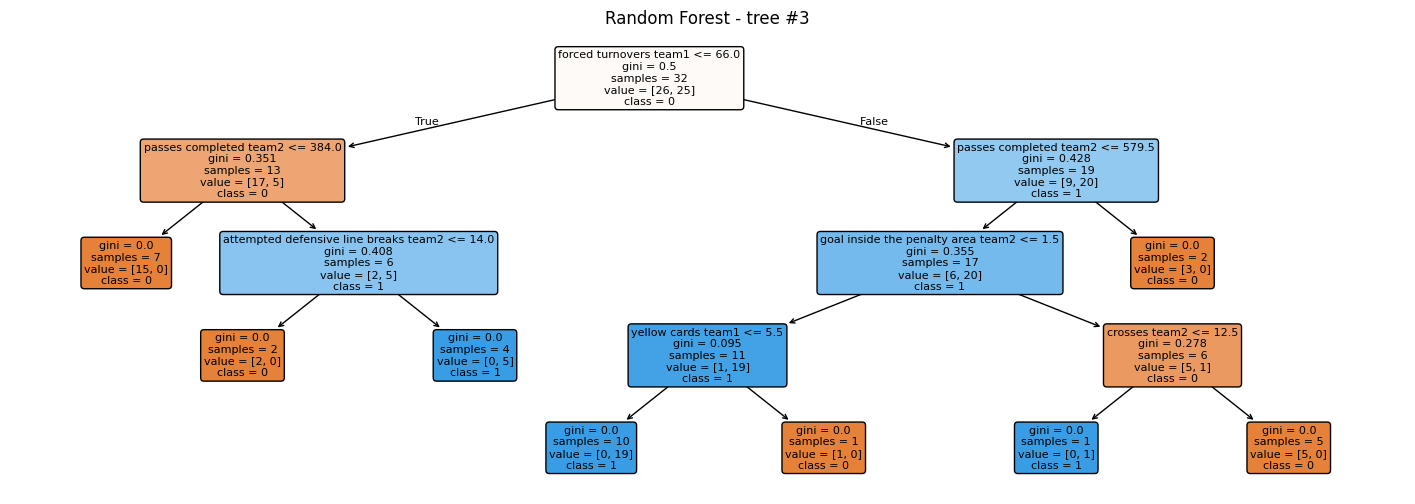

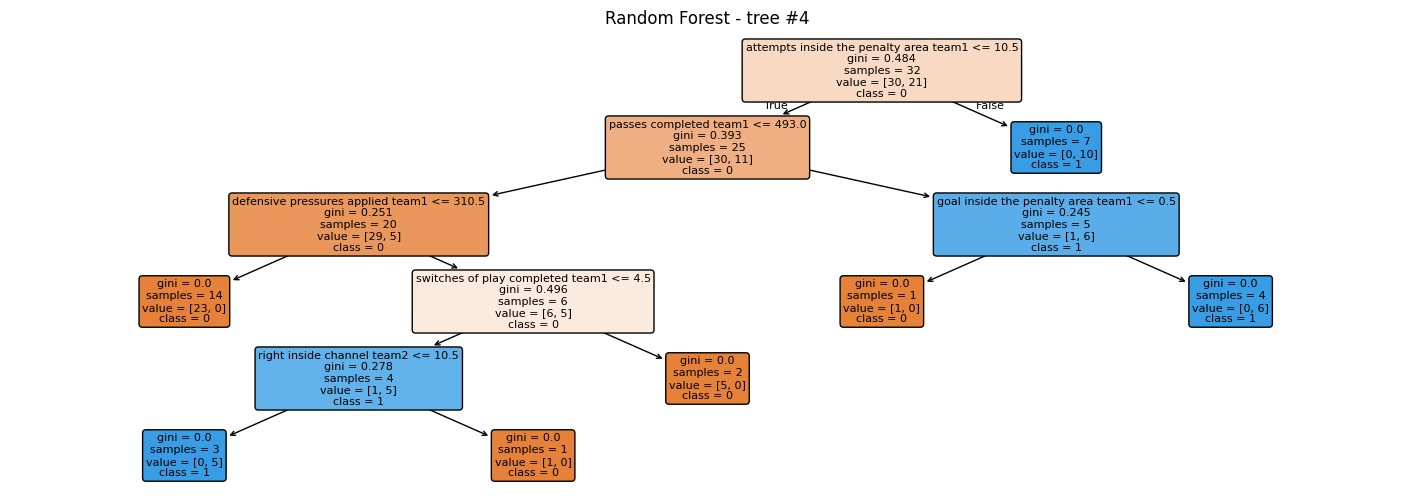

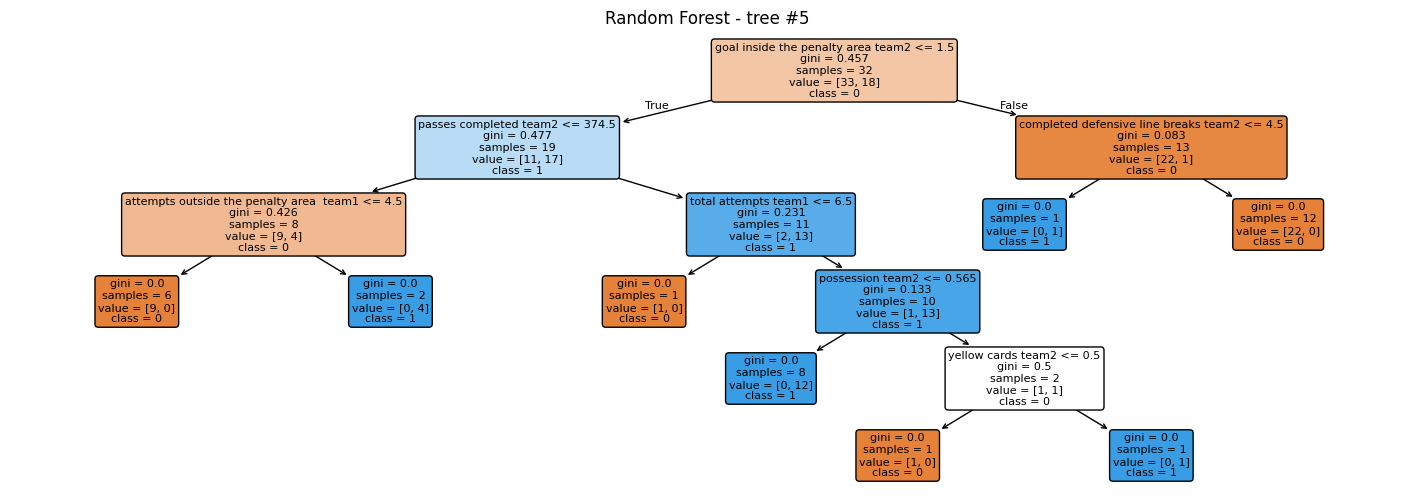

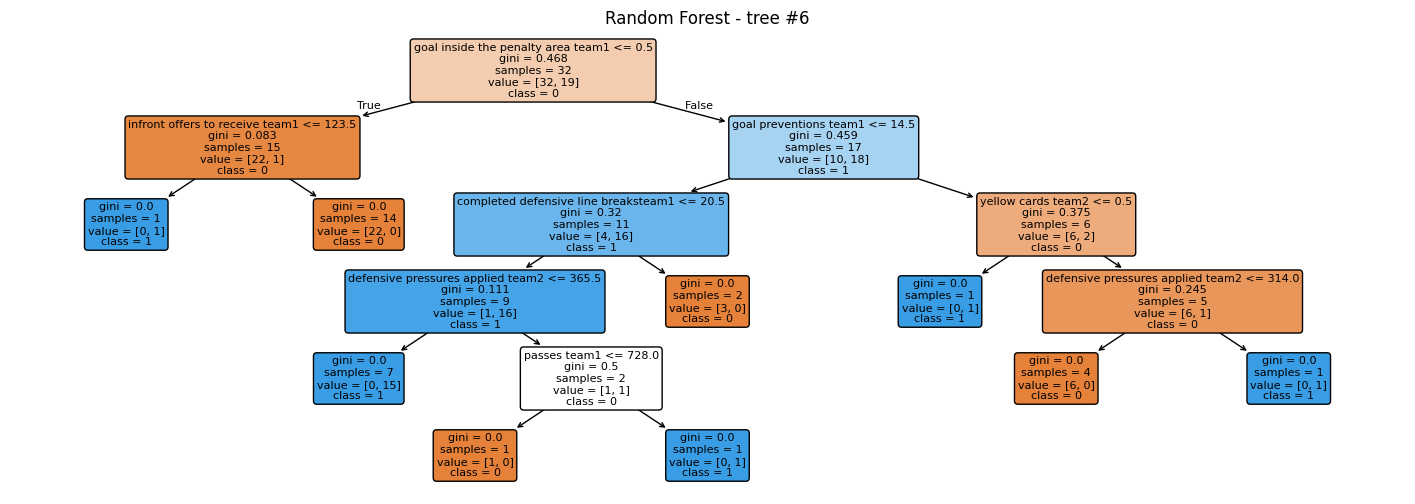

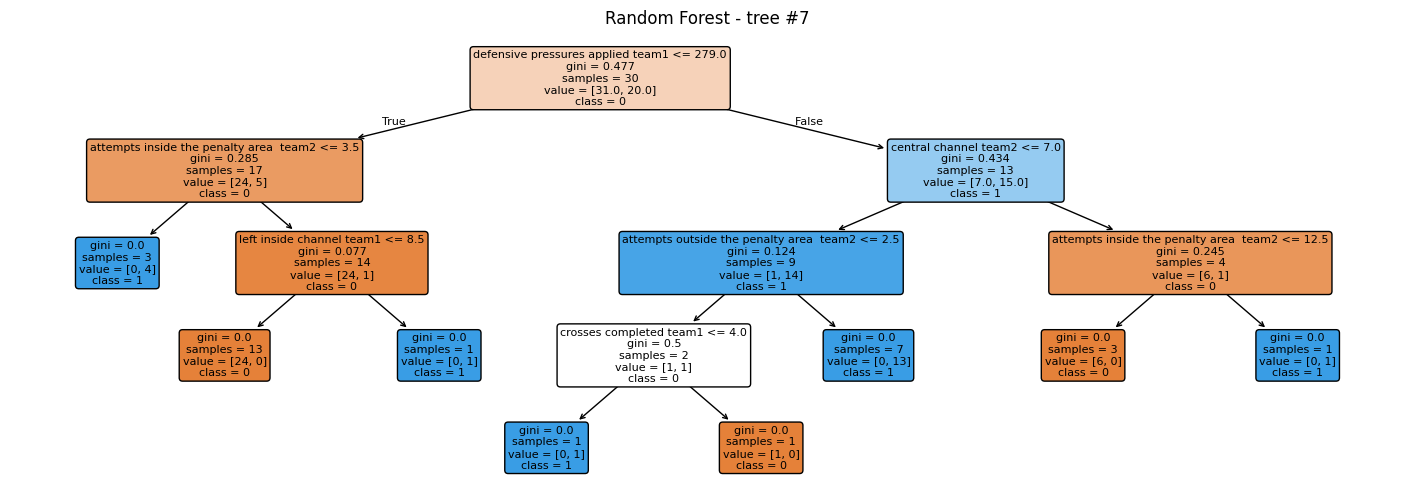

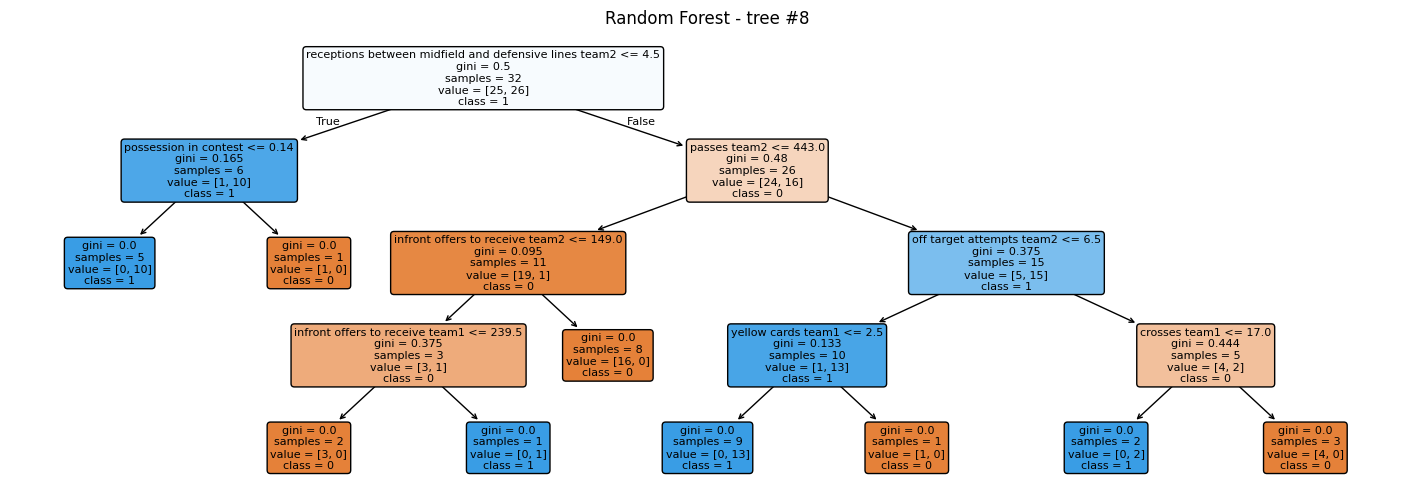

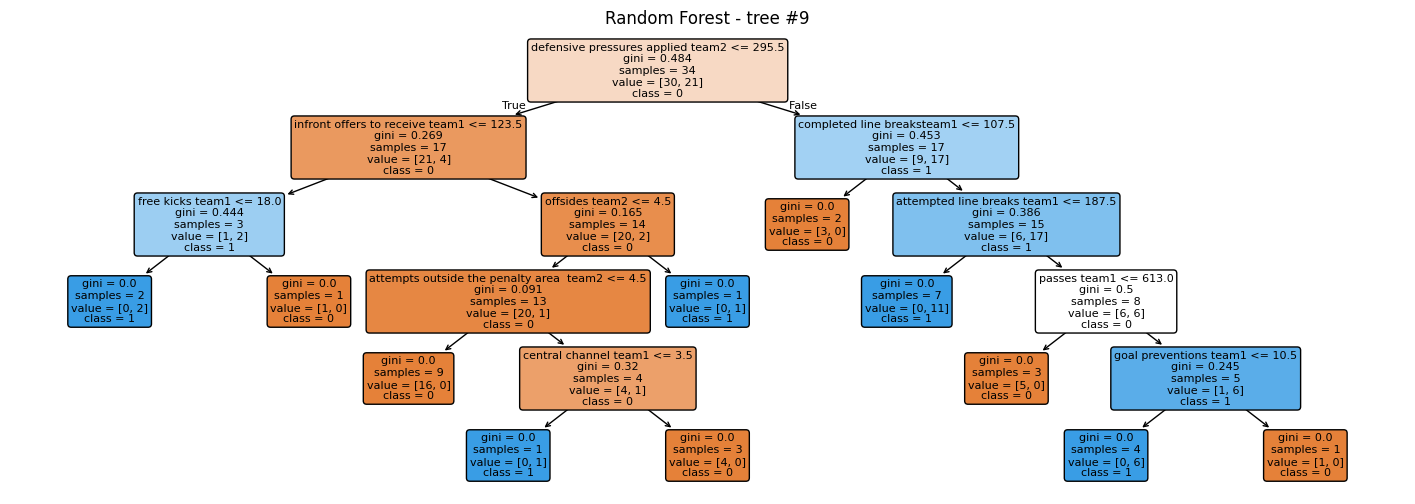

In [95]:
import matplotlib.pyplot as plt
from sklearn import tree

n_trees = len(rf.estimators_)
print(f"Num RandomForest trees: {n_trees}")


N = min(10, n_trees) # change int to see more or less trees


for i, est in enumerate(rf.estimators_[:N]):
    plt.figure(figsize=(18,6))
    tree.plot_tree(
        est,
        feature_names=X.columns,
        class_names=[str(c) for c in rf.classes_],
        filled=True,
        rounded=True,
        fontsize=8
    )
    plt.title(f"Random Forest - tree #{i}")
    plt.show()

In [85]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.80      0.67         5
           1       0.83      0.62      0.71         8

    accuracy                           0.69        13
   macro avg       0.70      0.71      0.69        13
weighted avg       0.73      0.69      0.70        13



In [86]:
# Show the most important features in the dataset for predicting outcome
features = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

features.head(30)

,feature,importance
0,assists team1,0.050842
1,goal inside the penalty area team1,0.048192
2,on target attempts team1,0.046425
3,goal inside the penalty area team2,0.043251
4,total offers to receive team1,0.028132
5,passes team2,0.025592
6,left inside channel team1,0.025580
7,assists team2,0.024574
8,defensive pressures applied team1,0.023885
9,infront offers to receive team1,0.022831
